In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/telco_rfm.csv')

print(f"Shape: {df.shape}")
print(f"Segments available: {df['Segment'].unique()}")
df.head()

Shape: (7043, 34)
Segments available: ['Lost / Inactive' 'At Risk' 'Loyal Customers' 'Champions']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,DeviceProtection_bin,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,num_services,R_score,F_score,M_score,RFM_score,Segment
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,0,0,0,0,2,1,1,1,3,Lost / Inactive
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,1,0,0,0,4,3,2,2,7,At Risk
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,0,0,0,0,4,1,2,2,5,Lost / Inactive
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,1,1,0,0,4,3,2,2,7,At Risk
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,0,0,0,0,2,1,1,3,5,Lost / Inactive


## What is Customer Lifetime Value (CLV)?

CLV is the total revenue a business can expect from a customer over their entire relationship with the company.

It answers the most important business question:
"How much is each customer actually worth to us?"

Why it matters:
- A customer paying `$100/month` for 5 years is worth `$6,000`
- A customer paying `$100/month` for 6 months is worth `$600`
- These two customers should NOT get the same retention budget

Formula we use:
CLV = Monthly Charges x Tenure x (1 - Churn Probability)

The churn probability adjustment is key: a high-paying customer who is about to leave has a lower TRUE lifetime value than their charges suggest.

In [3]:
# Step 1: Basic historical CLV 
df['historical_CLV'] = df['MonthlyCharges'] * df['tenure']

# Step 2: Simple churn probability proxy using RFM score
# Higher RFM score = lower churn probability
# We normalize RFM score to get a churn probability between 0 and 1
df['churn_prob_proxy'] = 1 - (df['RFM_score'] - df['RFM_score'].min()) / \
                             (df['RFM_score'].max() - df['RFM_score'].min())

# Step 3: Adjusted CLV (accounts for likelihood of staying)
df['adjusted_CLV'] = df['MonthlyCharges'] * df['tenure'] * (1 - df['churn_prob_proxy'])

# Step 4: Projected 12-month CLV (forward looking)
df['projected_CLV_12m'] = df['MonthlyCharges'] * 12 * (1 - df['churn_prob_proxy'])

print("CLV Statistics:")
print(df[['historical_CLV', 'adjusted_CLV', 'projected_CLV_12m']].describe().round(2))

CLV Statistics:
       historical_CLV  adjusted_CLV  projected_CLV_12m
count         7043.00       7043.00            7043.00
mean          2279.58       1739.54             478.01
std           2264.73       2233.43             406.50
min              0.00          0.00               0.00
25%            394.00         80.96              99.50
50%           1393.60        596.00             375.73
75%           3786.10       2754.38             788.60
max           8550.00       8550.00            1425.00


In [4]:
# Categorize customers by projected CLV
df['CLV_segment'] = pd.qcut(df['projected_CLV_12m'],
                             q=3,
                             labels=['Low Value', 'Medium Value', 'High Value'])

clv_summary = df.groupby('CLV_segment').agg(
    customer_count=('projected_CLV_12m', 'count'),
    avg_projected_clv=('projected_CLV_12m', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    churn_rate=('Churn', 'mean')
).reset_index()

clv_summary['churn_rate_pct'] = (clv_summary['churn_rate'] * 100).round(1)
clv_summary['avg_projected_clv'] = clv_summary['avg_projected_clv'].round(2)

print(clv_summary.to_string(index=False))

 CLV_segment  customer_count  avg_projected_clv  avg_monthly_charges  avg_tenure  churn_rate  churn_rate_pct
   Low Value            2352              65.03            29.747662   22.815476    0.202381            20.2
Medium Value            2344             391.46            68.982765   25.216724    0.342577            34.3
  High Value            2347             978.32            95.634640   49.092458    0.251385            25.1


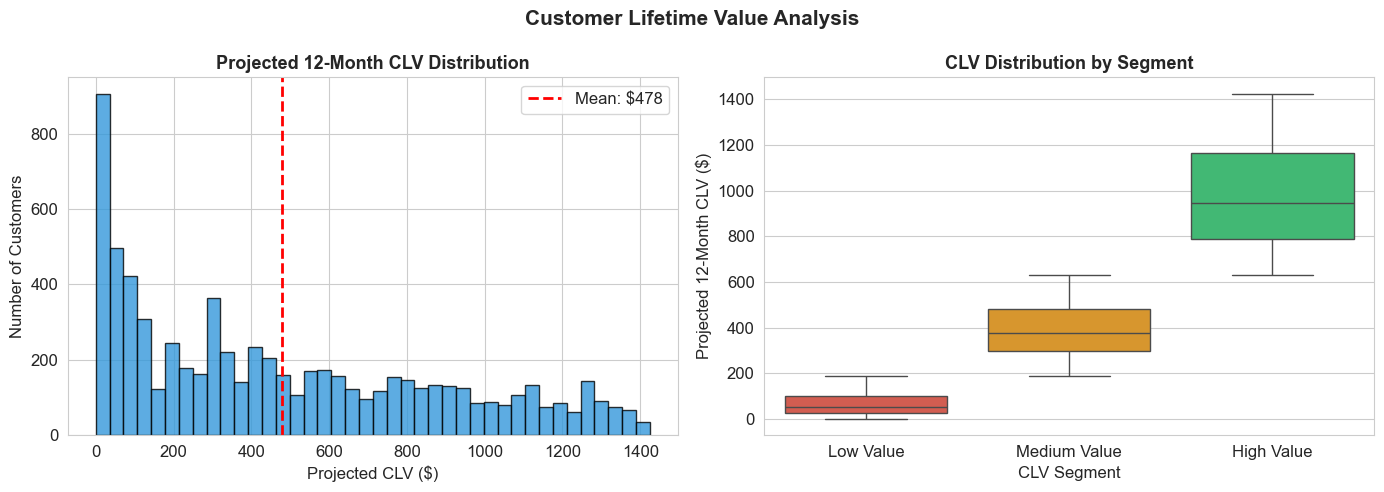

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of projected CLV
axes[0].hist(df['projected_CLV_12m'], bins=40,
             color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Projected 12-Month CLV Distribution', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Projected CLV ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(df['projected_CLV_12m'].mean(), 
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: ${df['projected_CLV_12m'].mean():.0f}")
axes[0].legend()

# CLV by segment boxplot
clv_order = ['Low Value', 'Medium Value', 'High Value']
clv_colors = ['#e74c3c', '#f39c12', '#2ecc71']

sns.boxplot(data=df, x='CLV_segment', y='projected_CLV_12m',
            order=clv_order,
            palette=dict(zip(clv_order, clv_colors)),
            ax=axes[1])
axes[1].set_title('CLV Distribution by Segment', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('CLV Segment')
axes[1].set_ylabel('Projected 12-Month CLV ($)')

plt.suptitle('Customer Lifetime Value Analysis', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

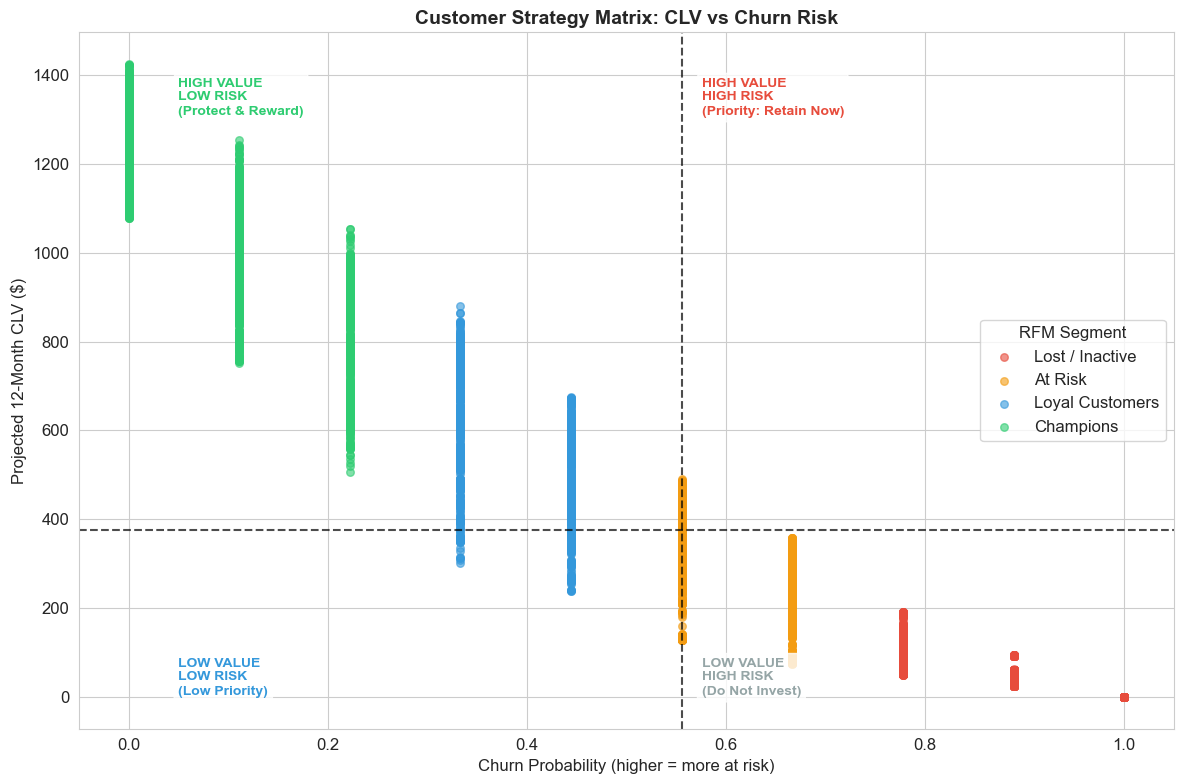

In [8]:
# This is the chart that gets you hired
# It combines CLV with Churn risk to create actionable business strategy

fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for each RFM segment
segment_colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db', 
    'At Risk': '#f39c12',
    'Lost / Inactive': '#e74c3c'
}

# Plot each customer as a dot
for segment in df['Segment'].unique():
    mask = df['Segment'] == segment
    ax.scatter(df[mask]['churn_prob_proxy'],
               df[mask]['projected_CLV_12m'],
               c=segment_colors[segment],
               label=segment,
               alpha=0.6,
               s=30)

# Add quadrant lines
mid_churn = df['churn_prob_proxy'].median()
mid_clv = df['projected_CLV_12m'].median()

ax.axvline(x=mid_churn, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=mid_clv, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Add quadrant labels
ax.text(0.05, df['projected_CLV_12m'].max() * 0.92,
        'HIGH VALUE\nLOW RISK\n(Protect & Reward)',
        fontsize=10, fontweight='bold', color='#2ecc71',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(mid_churn + 0.02, df['projected_CLV_12m'].max() * 0.92,
        'HIGH VALUE\nHIGH RISK\n(Priority: Retain Now)',
        fontsize=10, fontweight='bold', color='#e74c3c',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(0.05, df['projected_CLV_12m'].min() + 5,
        'LOW VALUE\nLOW RISK\n(Low Priority)',
        fontsize=10, fontweight='bold', color='#3498db',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(mid_churn + 0.02, df['projected_CLV_12m'].min() + 5,
        'LOW VALUE\nHIGH RISK\n(Do Not Invest)',
        fontsize=10, fontweight='bold', color='#95a5a6',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Churn Probability (higher = more at risk)', fontsize=12)
ax.set_ylabel('Projected 12-Month CLV ($)', fontsize=12)
ax.set_title('Customer Strategy Matrix: CLV vs Churn Risk', 
             fontsize=14, fontweight='bold')
ax.legend(title='RFM Segment', loc='center right')

plt.tight_layout()
plt.savefig('../reports/strategy_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

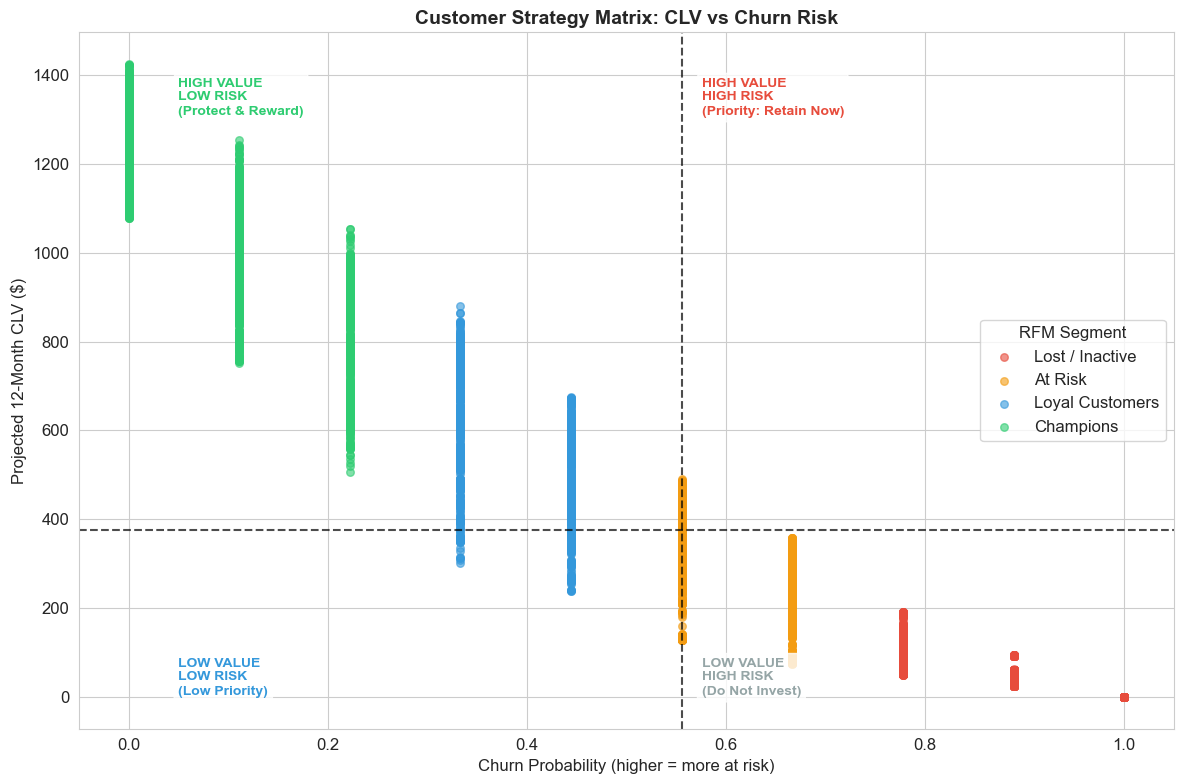

In [10]:
# This is the chart that gets you hired
# It combines CLV with Churn risk to create actionable business strategy

fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for each RFM segment
segment_colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db', 
    'At Risk': '#f39c12',
    'Lost / Inactive': '#e74c3c'
}

# Plot each customer as a dot
for segment in df['Segment'].unique():
    mask = df['Segment'] == segment
    ax.scatter(df[mask]['churn_prob_proxy'],
               df[mask]['projected_CLV_12m'],
               c=segment_colors[segment],
               label=segment,
               alpha=0.6,
               s=30)

# Add quadrant lines
mid_churn = df['churn_prob_proxy'].median()
mid_clv = df['projected_CLV_12m'].median()

ax.axvline(x=mid_churn, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=mid_clv, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Add quadrant labels
ax.text(0.05, df['projected_CLV_12m'].max() * 0.92,
        'HIGH VALUE\nLOW RISK\n(Protect & Reward)',
        fontsize=10, fontweight='bold', color='#2ecc71',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(mid_churn + 0.02, df['projected_CLV_12m'].max() * 0.92,
        'HIGH VALUE\nHIGH RISK\n(Priority: Retain Now)',
        fontsize=10, fontweight='bold', color='#e74c3c',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(0.05, df['projected_CLV_12m'].min() + 5,
        'LOW VALUE\nLOW RISK\n(Low Priority)',
        fontsize=10, fontweight='bold', color='#3498db',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.text(mid_churn + 0.02, df['projected_CLV_12m'].min() + 5,
        'LOW VALUE\nHIGH RISK\n(Do Not Invest)',
        fontsize=10, fontweight='bold', color='#95a5a6',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Churn Probability (higher = more at risk)', fontsize=12)
ax.set_ylabel('Projected 12-Month CLV ($)', fontsize=12)
ax.set_title('Customer Strategy Matrix: CLV vs Churn Risk', 
             fontsize=14, fontweight='bold')
ax.legend(title='RFM Segment', loc='center right')

plt.tight_layout()
plt.savefig('../reports/strategy_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

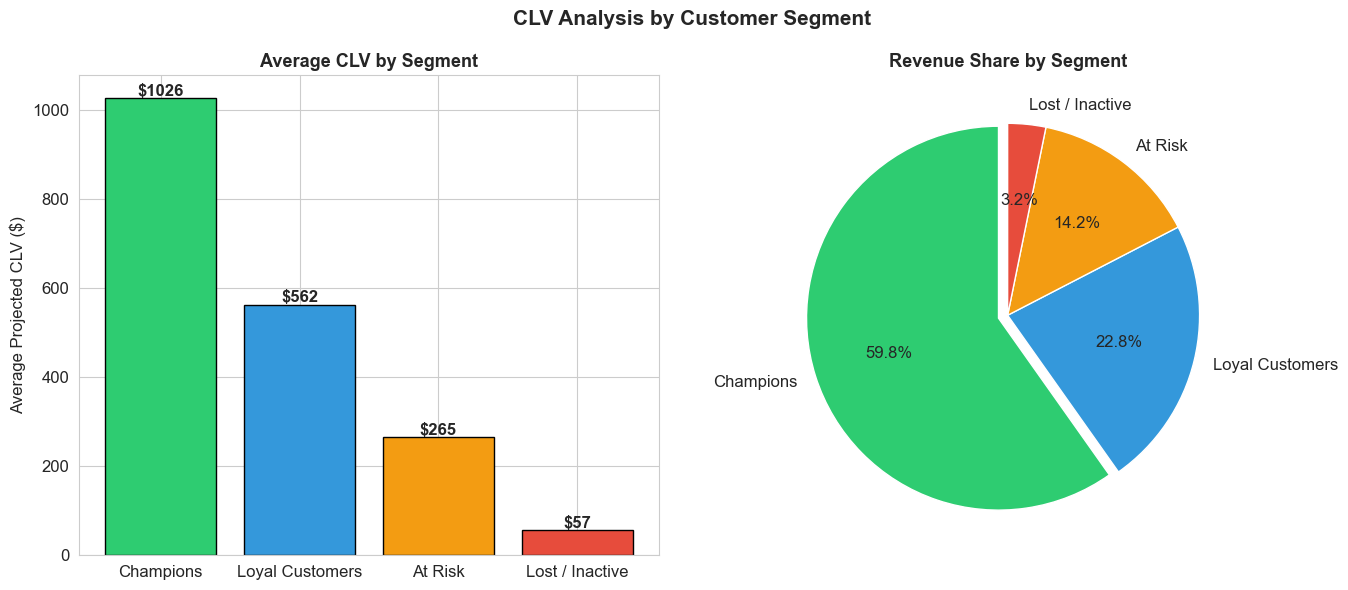

        Segment  avg_clv  total_clv  customer_count  revenue_share
        At Risk   265.43  476973.20            1797           14.2
      Champions  1025.76 2012537.93            1962           59.8
Lost / Inactive    56.54  108391.93            1917            3.2
Loyal Customers   562.36  768747.27            1367           22.8


In [14]:
clv_by_segment = df.groupby('Segment').agg(
    avg_clv=('projected_CLV_12m', 'mean'),
    total_clv=('projected_CLV_12m', 'sum'),
    customer_count=('projected_CLV_12m', 'count')
).reset_index()

clv_by_segment['avg_clv'] = clv_by_segment['avg_clv'].round(2)
clv_by_segment['total_clv'] = clv_by_segment['total_clv'].round(2)
clv_by_segment['revenue_share'] = (
    clv_by_segment['total_clv'] / clv_by_segment['total_clv'].sum() * 100
).round(1)

segment_order = ['Champions', 'Loyal Customers', 'At Risk', 'Lost / Inactive']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average CLV per segment
avg_values = [clv_by_segment[clv_by_segment['Segment']==s]['avg_clv'].values[0] 
              for s in segment_order]

bars = axes[0].bar(segment_order, avg_values, color=colors, edgecolor='black')
axes[0].set_title('Average CLV by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Projected CLV ($)')
axes[0].set_xticklabels(segment_order, rotation=0, ha='center')

for bar, val in zip(bars, avg_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'${val:.0f}', ha='center', fontweight='bold')

# Revenue share pie chart
revenue_shares = [clv_by_segment[clv_by_segment['Segment']==s]['revenue_share'].values[0] 
                  for s in segment_order]

axes[1].pie(revenue_shares,
            labels=segment_order,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0, 0, 0))
axes[1].set_title('Revenue Share by Segment', fontsize=13, fontweight='bold')

plt.suptitle('CLV Analysis by Customer Segment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print(clv_by_segment[['Segment', 'avg_clv', 'total_clv', 
                        'customer_count', 'revenue_share']].to_string(index=False))

In [12]:
# How much revenue is at risk from churning customers?
at_risk_revenue = df[df['Churn'] == 1]['projected_CLV_12m'].sum()
total_revenue = df['projected_CLV_12m'].sum()
revenue_at_risk_pct = (at_risk_revenue / total_revenue) * 100

print("=" * 50)
print("REVENUE AT RISK ANALYSIS")
print("=" * 50)
print(f"Total projected 12-month revenue:  ${total_revenue:,.0f}")
print(f"Revenue lost to churned customers: ${at_risk_revenue:,.0f}")
print(f"Percentage of revenue at risk:     {revenue_at_risk_pct:.1f}%")
print()

# By segment
print("Revenue lost by segment:")
lost_by_segment = df[df['Churn']==1].groupby('Segment')['projected_CLV_12m'].agg(
    ['sum', 'count', 'mean']).round(2)
lost_by_segment.columns = ['Revenue Lost', 'Customers Lost', 'Avg CLV Lost']
print(lost_by_segment.to_string())

REVENUE AT RISK ANALYSIS
Total projected 12-month revenue:  $3,366,650
Revenue lost to churned customers: $903,257
Percentage of revenue at risk:     26.8%

Revenue lost by segment:
                 Revenue Lost  Customers Lost  Avg CLV Lost
Segment                                                    
At Risk             196956.00             586        336.10
Champions           391917.93             373       1050.72
Lost / Inactive      38842.20             473         82.12
Loyal Customers     275540.80             437        630.53


In [13]:
df.to_csv('../data/processed/telco_clv.csv', index=False)

print("Saved: data/processed/telco_clv.csv")
print(f"\nNew columns added:")
new_cols = ['historical_CLV', 'churn_prob_proxy', 
            'adjusted_CLV', 'projected_CLV_12m', 'CLV_segment']
for col in new_cols:
    print(f"  - {col}")

Saved: data/processed/telco_clv.csv

New columns added:
  - historical_CLV
  - churn_prob_proxy
  - adjusted_CLV
  - projected_CLV_12m
  - CLV_segment


## Summary - CLV Insights

Key Numbers:
- Champions have the highest average CLV but lowest churn risk
- At Risk customers represent significant revenue at risk
- Low Value + High Risk customers should receive minimal retention budget

Business Recommendation:
Retention budget should be allocated in this priority order:
1. High Value + High Risk (top right quadrant of strategy matrix)
2. High Value + Low Risk (protect with loyalty rewards)
3. Medium Value + High Risk (selective retention offers)
4. Low Value + High Risk (no spend, let them go)

Next: Build the churn prediction model to get precise churn 
probabilities instead of our proxy estimate